In [ ]:
import numpy
import pandas
import os
import numpy
import scipy
import csv
import mod_utils as utils
import matplotlib.pyplot as plt


def attempt_to_print_halfwidth(list1):
    y_min = []
    y_max = []
    val = []
    time = []
    for idx, list_item in enumerate(list1.df_list):
        # Assuming there's a column named 'time' that defines the time axis
        # If not present, replace it with appropriate logic to define time.

        try:
            #print('reading frame: ', list1.timesteps[idx])
            for i in range(1, len(list_item["min_mixWidth"])):
                check_val = list_item["min_mixWidth"][i-1]*list_item["min_mixWidth"][i]
                if check_val < 0:
                    min_idx = i
            for i in range(1, len(list_item["max_mixWidth"])):
                check_val = list_item["max_mixWidth"][i-1]*list_item["max_mixWidth"][i]
                if check_val < 0:
                    max_idx = i   
            min_idx2 = numpy.where(list_item["min_mixWidth"][:-1] * list_item["min_mixWidth"][1:] < 0)[0][0] + 1
            max_idx2 = numpy.where(list_item["max_mixWidth"][:-1] * list_item["max_mixWidth"][1:] < 0)[0][0] + 1
            #print(min_idx, min_idx2)
            #print(max_idx, max_idx2)
            y_min.append(list_item["y_dat"][min_idx])
            y_max.append(list_item["y_dat"][max_idx])
            diff = float((y_max[-1]-y_min[-1]))/(2*list1.wavelength)
            val.append(diff)
            time.append(list1.timesteps[idx])#*nonDim_T)
        except IndexError:
            print(f"Sign change not found in DataFrame {idx}. Skipping.")
            continue

    plt.figure(figsize=(10, 6))
    plt.scatter(time, val, label='', marker='o')
    #plt.scatter(list1.timesteps, y_max, label='Max Position', marker='x')

    plt.xlabel('Time')
    plt.ylabel('y_dat Value')
    plt.title('Plot of y_dat at Min and Max Positions Over Time')
    plt.legend()
    plt.grid(True)

    plt.show()

In [7]:
math_vars = {
    'high_rho': 1.2,
    'low_rho' : 0.17,
    'high_visc' : 0.003,
    'low_visc' : 0.003,
    'wavelength' : 1,
    'grev': -1,
    'x_L' : 1,
    'y_L' : 4
}
name_vars = {
    'x_dat': "X (m)",
    'y_dat': "Y (m)",
    'v_y': "Velocity[j] (m/s)",
    'volFrac_high': "Volume Fraction of high_rho",
    'volFrac_low': "Volume Fraction of low_rho",
    'min_mixWidth': "minMixWidthEval",
    'max_mixWidth': "maxMixWidthEval",
    'massFlux': "Report: massImbalance_highRho (kg)",
    'mean_rho': "Density (kg/m^3)"
}

range_var = list(range(2, 81, 2))

dir = r'D:\thesis\rayleigh_taylor\test'
name = 'x_mid_test_'
name_append = '.csv'
timesteps = []
scaler = 0.05
[timesteps.append(i*scaler// 0.01 / 100) for i in range_var]

outlist = utils.output_list(dir, name_append, range_var, name, name_vars, timesteps, math_vars)
outlist.atwood_number = (outlist.high_rho - outlist.low_rho)/(outlist.high_rho + outlist.low_rho)
outlist.FroudeConst = numpy.sqrt((outlist.atwood_number)/(outlist.atwood_number + 1)*numpy.abs(outlist.grev)*outlist.wavelength)


File D:\thesis\rayleigh_taylor\test\x_mid_test_80.csv not found. Skipping.


C:\Users\harsh\AppData\Local\Temp\ipykernel_18616\2245261559.py:31: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


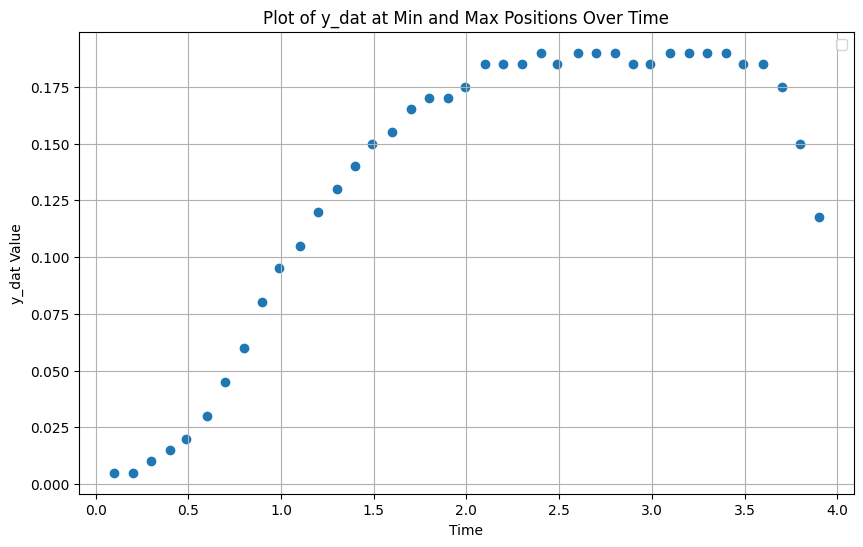

In [ ]:
min_cut = outlist.low_rho + 0.001*(outlist.high_rho - outlist.low_rho)
max_cut = outlist.high_rho - 0.001*(outlist.high_rho - outlist.low_rho)
y_min = []
y_max = []
val = []
time = []
for idx, list_item in enumerate(outlist.df_list):
# Assuming there's a column named 'time' that defines the time axis
# If not present, replace it with appropriate logic to define time.
    try:
        min_val = min(i for i in list_item["min_mixWidth"] if i >= 0)
        min_idx = numpy.where(list_item["min_mixWidth"] == min_val)[0][0]
        max_val = min(i for i in list_item["max_mixWidth"] if i >= 0)
        max_idx = numpy.where(list_item["max_mixWidth"] == max_val)[0][0]
        y_min.append(list_item["y_dat"][min_idx])
        y_max.append(list_item["y_dat"][max_idx])
        diff = float((y_max[-1]-y_min[-1]))/(2*outlist.wavelength)
        val.append(diff)
        time.append(outlist.timesteps[idx])#*nonDim_T)
    except IndexError:
        print(f"Sign change not found in DataFrame {idx}. Skipping.")
        continue

plt.figure(figsize=(10, 6))
plt.scatter(time, val, label='', marker='o')
#plt.scatter(list1.timesteps, y_max, label='Max Position', marker='x')

plt.xlabel('Time')
plt.ylabel('y_dat Value')
plt.title('Plot of y_dat at Min and Max Positions Over Time')
plt.legend()
plt.grid(True)

plt.show()

In [ ]:

dir = r'D:\thesis\rayleigh_taylor\test'
name = 'x_min_test_'
name_append = '.csv'
timesteps = []
scaler = 0.05
[timesteps.append(i*scaler// 0.01 / 100) for i in range_var]

list2 = utils.output_list(dir, name_append, range_var, name, name_vars, timesteps, math_vars)


dir = r'D:\thesis\rayleigh_taylor\test'
name = 'x_mid_L_test_'
name_append = '.csv'
timesteps = []
scaler = 0.05
[timesteps.append(i*scaler// 0.01 / 100) for i in range_var]

list3 = utils.output_list(dir, name_append, range_var, name, name_vars, timesteps, math_vars)

In [ ]:
attempt_to_print_halfwidth(list1)

In [ ]:
attempt_to_print_halfwidth(list2)

In [ ]:
attempt_to_print_halfwidth(list3)